#### Run of show (presenter navigation)

Links jump to the cell in Colab. Companion to `A2-sprint-review-script.md`.

- **0:00** — [Open — title & scenario](#scrollTo=DNeUJ_So73h8)
- **0:21** — [Part 1 — the Gaussian nudge](#scrollTo=xjLguRuh_BR_)
- **1:16** — [Interlude — re-evaluation](#scrollTo=Y_SilAMIJ8Pb)
- **1:23** — [Interlude — score distribution](#scrollTo=hP1SgodyPQJq)
- **1:29** — [Part 2 — fixed topology graph](#scrollTo=U0aP_So0ZsQ1)
- **1:51** — [Part 2 — NEAT topology graph](#scrollTo=oP4iGopnVeCx)
- **2:41** — [Part 3 — StdOutReporter log](#scrollTo=k3qyp5yrN_hW)
- **3:30** — [Part 3 — compatibility distance](#scrollTo=f71d60dec3c7)
- **3:59** — [Clips — GA video](#scrollTo=U0aP_So0ZsQ1)
- **4:05** — [Clips — NEAT video](#scrollTo=jPSZjLp5VXTj)
- **4:11** — [Close — run comparison plot](#scrollTo=8RS0jiy2fd1W)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geraldmc/unified-labs/blob/main/the_genetic_programmer/Assignment-2.ipynb)


## Understanding the CartPole-v1 Environment

Before we begin optimizing our AI, let's familiarize ourselves with the `CartPole-v1` environment provided by Gymnasium.

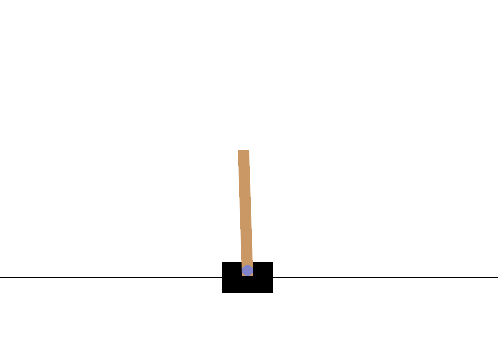

**Observation Space (State):**
The environment returns an array of 4 floating-point numbers representing the current physical state:
1. **Cart Position:** The horizontal position of the cart.
2. **Cart Velocity:** The speed at which the cart is moving left or right.
3. **Pole Angle:** The angle of the pole in radians (0 is perfectly vertical).
4. **Pole Angular Velocity:** The speed at which the pole is falling.

**Action Space:**
Your AI must output a single discrete integer each step:
* `0`: Push the cart to the **left**.
* `1`: Push the cart to the **right**.

**Goal:**
You receive a reward of +1 for every step the pole remains upright. The episode ends if the pole leans too far (more than 12 degrees), the cart moves off-screen, or the system successfully survives for 500 steps.

# Assignment 2: Architecture Showdown - Fixed GA vs Fluid GP (Modules 2, 3)

## The Scenario
Welcome back to **Synthetica**. The Global Defense Initiative has commissioned you to build the AI control system for a kinetic energy stabilization platform. The platform must perfectly balance a heavy inverted pendulum on a moving cart to maintain a target lock.

The sensors provide you with 4 inputs: Cart Position, Cart Velocity, Pole Angle, and Pole Velocity. Your AI must process these inputs and output a binary decision: apply force to the **Left (0)** or **Right (1)**.

In this capstone assignment, you will attempt to solve this environment using two drastically different evolutionary paradigms:
1. **Part 1 (Fixed Architecture):** You will use the skills you learned in Module 2 to build a continuous-parameter Genetic Algorithm from scratch. You will evolve the weights of a rigid, predefined Neural Network.
2. **Part 2 (Fluid Architecture):** You will use the skills from Module 3 to deploy `neat-python`, a state-of-the-art library that evolves both the weights *and* the underlying topology of the network.

In [1]:
!pip install gymnasium > /dev/null 2>&1
import gymnasium as gym

# Initialize the environment
env = gym.make('CartPole-v1')
state, info = env.reset()
print(f"Initial State Array: {state}")

# Sample a random action (0 or 1)
random_action = env.action_space.sample()
action_name = 'Right' if random_action == 1 else 'Left'
print(f"\nTaking Random Action: {random_action} ({action_name})")

# Step the physics engine forward by one frame
next_state, reward, terminated, truncated, info = env.step(random_action)

print(f"Next State Array: {next_state}")
print(f"Reward received: {reward}")
print(f"Did the platform crash? (Terminated): {terminated}")

env.close()

Initial State Array: [ 0.04284337  0.03734295  0.03914017 -0.01665176]

Taking Random Action: 0 (Left)
Next State Array: [ 0.04359023 -0.15831782  0.03880714  0.2881189 ]
Reward received: 1.0
Did the platform crash? (Terminated): False


## Milestone 1: Set Up

*Run this cell to load the `simulate_cartpole` function. This function takes your chromosome of 25 floats, runs it through the Gym physics engine, and returns the total time steps the pole stayed balanced (up to a maximum of 500). You will complete the `feedforward_pass` function in Milestone 1.*

In [2]:
# MILESTONE 1 SETUP - RUN THIS CELL FIRST
import random
import math

def simulate_cartpole(chromosome, render=False):
    """
    Simulates one episode of CartPole.
    Relies on the student's feedforward_pass() function to make decisions.
    """
    env = gym.make('CartPole-v1')
    state, _ = env.reset()
    total_reward = 0

    # Unpack the flat chromosome into two weight matrices
    # W1 is 4x5 (Inputs to Hidden), W2 is 5x1 (Hidden to Output)
    W1 = [chromosome[i:i+5] for i in range(0, 20, 5)]
    W2 = chromosome[20:25]

    done = False
    while not done and total_reward < 500:

        # --- THIS CALLS THE STUDENT'S FUNCTION ---
        action = feedforward_pass(state, W1, W2)

        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

    env.close()
    return total_reward

print("Synthetica Environment Loop Loaded.")

Synthetica Environment Loop Loaded.


## Milestone 1: The Fixed-Weight Genetic Algorithm
**Objective:** You will build a GA to optimize a simple Neural Network with 4 input nodes, 5 hidden nodes, and 1 output node. Because we are omitting biases to keep the math simple, this network requires exactly **25 weights** (4x5 = 20 connections to the hidden layer, and 5x1 = 5 connections to the output layer).

Unlike Lab 2 (where DNA was integers), your chromosomes here will be arrays of 25 **floating-point numbers**.

### The Architect's Blueprint
*Write the continuous GA operators and the main execution loop to train your network.*

* **0. The Neural Network (Feedforward):** Write `feedforward_pass(state, W1, W2)`.
    * *Hidden Layer:* Create an empty list called `hidden`. For each of the 5 hidden nodes, calculate the dot product of the 4 `state` inputs and the node's corresponding 4 weights in `W1`. Apply a **ReLU activation** (if the sum is less than 0, set it to 0) and append it to `hidden`.
    * *Output Layer:* Calculate the dot product of the 5 `hidden` values and the 5 weights in `W2`.
    * *Activation & Action:* Apply a **Sigmoid activation** to the output sum: `prob = 1.0 / (1.0 + math.exp(-out_sum))`. *(Hint: cap out_sum between -500 and 500 to prevent math overflow errors).* If `prob > 0.5`, return `1` (Right). Otherwise, return `0` (Left).
* **1. Initializer:** Write `generate_chromosome()`. Return a list of 25 random floats between `-1.0` and `1.0`.
* **2. Crossover:** Write `uniform_crossover(parent1, parent2)`. Loop 25 times. At each index, flip a coin. If heads, append the gene from `parent1` to the child; if tails, append from `parent2`. Return **one** child array.
* **3. Mutation:** Write `gaussian_mutation(chromosome, rate)`. Loop through the chromosome. If a random roll is less than `rate`, do not replace the gene with a new number. Instead, *nudge* it by adding Gaussian noise: `chromosome[i] += random.gauss(0, 0.5)`. Return the mutated chromosome.
* **4. The Main Loop:** Write `run_fixed_ga(pop_size, generations, mutation_rate)`.
    * Initialize a population of `pop_size`.
    * Loop for `generations`:
        * Evaluate the fitness of every chromosome using our provided `simulate_cartpole(chrom)` function.
        * Sort the population from highest fitness to lowest.
        * *Early Stopping:* If the best fitness hits `500.0` (a perfect score), print the generation and stop the loop.
        * Keep a percentage of the population unchanged (Elitism).
        * Fill the rest of the new population by selecting two random parents from the top 50%, crossing them over to make a child, mutating the child, and appending it.
    * Return the single best chromosome found and its fitness score.

In [3]:
# ENTER YOUR CODE
# =====================================================================
# MILESTONE 1 — CODE
# =====================================================================

import math
import random
import statistics
from typing import Optional, Sequence


def feedforward_pass(state: Sequence[float],
                     W1: Sequence[Sequence[float]],
                     W2: Sequence[float]) -> int:
    """One forward pass. Returns 1 (push right) or 0 (push left).

    W1 is 4 rows x 5 columns: row i holds the weights leaving input i.
    W2 is 5 weights, one per hidden node.

    Note: the sigmoid is decorative. Thresholding 1/(1+e^-z) at 0.5 is
    identical to thresholding z at 0, because the sigmoid is monotone
    and sigmoid(0) = 0.5 exactly. It is implemented as specified.
    """
    hidden = []
    for j in range(5):
        total = 0.0
        for i in range(4):
            total += state[i] * W1[i][j]
        hidden.append(total if total > 0.0 else 0.0)        # ReLU

    out_sum = 0.0
    for j in range(5):
        out_sum += hidden[j] * W2[j]

    out_sum = max(-500.0, min(500.0, out_sum))              # overflow guard
    prob = 1.0 / (1.0 + math.exp(-out_sum))
    return 1 if prob > 0.5 else 0


def generate_chromosome(rng: Optional[random.Random] = None) -> list:
    """25 random floats in [-1.0, 1.0]."""
    r = rng or random
    return [r.uniform(-1.0, 1.0) for _ in range(25)]


def uniform_crossover(parent1: Sequence[float],
                      parent2: Sequence[float],
                      rng: Optional[random.Random] = None) -> list:
    """One child. Independent coin flip per gene."""
    r = rng or random
    return [parent1[i] if r.random() < 0.5 else parent2[i] for i in range(25)]


def gaussian_mutation(chromosome: list,
                      rate: float,
                      sigma: float = 0.5,
                      rng: Optional[random.Random] = None) -> list:
    """Nudge genes rather than replace them. Mutates in place and returns.
        ON SCREEN — Milestone 1 code cell"""
    r = rng or random
    for i in range(len(chromosome)):
        if r.random() < rate:
            chromosome[i] += r.gauss(0, sigma)  # nudge the gene, don't replace it
    return chromosome


def run_fixed_ga(pop_size: int = 15,
                 generations: int = 30,
                 mutation_rate: float = 0.1,
                 elite_fraction: float = 0.2,
                 rng: Optional[random.Random] = None,
                 verbose: bool = True):
    """Evolve 25 network weights. Returns (best_chromosome, best_fitness).

    Three choices the blueprint left open, made explicit:
      elite_fraction  the blueprint says "keep a percentage" without a number
      parent pool     top 50%, sampled uniformly with replacement, as specified
      rng             makes the operators reproducible; the environment is not
                      seedable through the provided simulate_cartpole
    """
    r = rng or random
    population = [generate_chromosome(r) for _ in range(pop_size)]

    n_elite = max(1, int(round(elite_fraction * pop_size)))
    n_parents = max(2, pop_size // 2)

    best_chromosome, best_fitness = None, -1.0

    for gen in range(generations):
        scored = sorted(((simulate_cartpole(c), c) for c in population),
                        key=lambda pair: pair[0], reverse=True)

        if scored[0][0] > best_fitness:
            best_fitness, best_chromosome = scored[0][0], list(scored[0][1])

        if verbose:
            mean_fit = statistics.mean(s for s, _ in scored)
            print(f"  gen {gen:2d}  best {scored[0][0]:5.1f}  mean {mean_fit:6.1f}")

        if scored[0][0] >= 500.0:
            if verbose:
                print(f"  Perfect score reached at generation {gen}. Stopping.")
            break

        parents = [c for _, c in scored[:n_parents]]
        next_population = [list(c) for _, c in scored[:n_elite]]   # elitism
        while len(next_population) < pop_size:
            p1, p2 = r.choice(parents), r.choice(parents)
            child = uniform_crossover(p1, p2, r)
            next_population.append(gaussian_mutation(child, mutation_rate, rng=r))
        population = next_population

    return best_chromosome, best_fitness

### The Test Harness
*Run this code to deploy your Fixed-Weight GA. We will give it a population of 50 and let it run for up to 30 generations.*


In [4]:
# MILESTONE 1 TEST HARNESS

print("Initializing Fixed-Weight GA Engine...")
best_weights, best_score = run_fixed_ga(
    pop_size=15,
    generations=30,
    mutation_rate=0.1
)

print("\n--- EVOLUTION HALTED ---")
print(f"Final Fitness Score: {best_score} / 500.0 steps")

if best_score == 500.0:
    print("SUCCESS: The Fixed-Weight GA successfully stabilized the CartPole platform!")
else:
    print("WARNING: The platform crashed. Try tweaking the hyper-parameters or rerunning.")

Initializing Fixed-Weight GA Engine...
  gen  0  best 163.0  mean   30.7
  gen  1  best 483.0  mean  101.3
  gen  2  best 500.0  mean  139.4
  Perfect score reached at generation 2. Stopping.

--- EVOLUTION HALTED ---
Final Fitness Score: 500.0 / 500.0 steps
SUCCESS: The Fixed-Weight GA successfully stabilized the CartPole platform!


#### Re-evaluating the winner over 200 episodes

In [5]:
# =====================================================================
# MILESTONE 1 — HONEST RE-EVALUATION
# =====================================================================
# The harness above declares success on a SINGLE episode from a random
# initial state. Lecture 6 (Gymnasium tutorial) makes the opposite
# argument and evaluates over 100 episodes. This cell does that, and
# does it reproducibly.

import gymnasium as gym


def evaluate(policy, episodes: int = 200, seed: int = 1000) -> list:
    """Score any policy over `episodes` seeded episodes.

    Args:
        policy: a callable taking a state and returning 0 or 1. Works for
                both the fixed-weight GA network and a NEAT genome.
    """
    env = gym.make('CartPole-v1')
    scores = []
    for k in range(episodes):
        state, _ = env.reset(seed=seed + k)
        total, done = 0.0, False
        while not done and total < 500:
            state, reward, terminated, truncated, _ = env.step(policy(state))
            done = terminated or truncated
            total += reward
        scores.append(total)
    env.close()
    return scores

def ga_policy(chromosome):
    """Wrap a 25-gene chromosome as a state -> action function."""
    W1 = [chromosome[i:i + 5] for i in range(0, 20, 5)]
    W2 = chromosome[20:25]
    return lambda state: feedforward_pass(state, W1, W2)

def report(scores: list, label: str) -> None:
    hits = sum(1 for s in scores if s >= 500)
    print(f"{label}")
    print(f"  episodes         : {len(scores)}")
    print(f"  mean             : {statistics.mean(scores):.1f} / 500")
    print(f"  median           : {statistics.median(scores):.1f}")
    print(f"  range            : {min(scores):.0f} - {max(scores):.0f}")
    print(f"  std deviation    : {statistics.pstdev(scores):.1f}")
    print(f"  episodes at 500  : {hits}/{len(scores)} ({100 * hits / len(scores):.0f}%)")


scores = evaluate(ga_policy(best_weights), episodes=200, seed=1000)
report(scores, "Fixed-Weight GA winner, re-evaluated on fresh episodes:")

Fixed-Weight GA winner, re-evaluated on fresh episodes:
  episodes         : 200
  mean             : 480.7 / 500
  median           : 500.0
  range            : 45 - 500
  std deviation    : 74.0
  episodes at 500  : 159/200 (80%)


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_score_distribution(scores: list, ax=None):
    """Show how one controller's episode scores are actually distributed.

    The test harness reports a single episode. This plots the full set of
    episode scores behind that number, split by whether the episode was a
    success (balanced the full 500 steps) or a failure (crashed early).

    The distribution is bimodal in practice: episodes tend to either go the
    distance or die well before 350, with little in between. That is why
    the summary statistic worth quoting is the success rate, not the mean —
    the mean falls in the empty gap between the two clumps and describes
    no episode that actually occurred.

    Args:
        scores: episode scores from evaluate(), one per episode.
        ax:     an existing matplotlib axis to draw on. A new figure is
                created when this is None.

    Returns:
        The axis, so the caller can adjust it before showing or saving.
    """

    sns.set_theme(style="whitegrid", context="notebook")

    df = pd.DataFrame({"score": scores})
    df["outcome"] = ["Balanced all 500 steps" if s >= 500 else "Crashed early"
                     for s in df["score"]]

    mean_score = statistics.mean(scores)
    rate = 100 * (df["score"] >= 500).sum() / len(df)

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.5))

    # Colour by outcome rather than position. Without this, the failure mass
    # and the success spike read as one distribution seen at two x values,
    # which is the opposite of the point.
    #
    # stack, not dodge: the two groups never share a bin (failures are all
    # below 500, successes all at 500), so stacking leaves every bar at its
    # true x position instead of shifting it sideways to make room.
    sns.histplot(
        data=df, x="score", hue="outcome", bins=25, multiple="stack",
        palette={"Balanced all 500 steps": "#2a7f62", "Crashed early": "#c1442e"},
        edgecolor="white", linewidth=0.5, ax=ax,
    )

    # The mean is drawn to be argued against, not to summarise. Labelling it
    # is the whole reason it is on the chart.
    ax.axvline(mean_score, color="0.35", linestyle=":", linewidth=2)
    # Only claim the gap when there actually is one.
    window = [s for s in scores if abs(s - mean_score) < 25]
    gap_note = ("\nalmost no episode\nscores near it"
                if len(window) / len(scores) < 0.05 else "")
    ax.annotate(
        f"mean = {mean_score:.0f}{gap_note}",
        xy=(mean_score, ax.get_ylim()[1] * 0.55),
        xytext=(8, 0), textcoords="offset points",
        color="0.35", fontsize=10, va="center",
    )
    # 500 is deliberately NOT drawn as a vertical line. The tallest bar sits
    # at 500, so a line there reads as agreement with the harness. Stating it
    # in the title makes it a claim the audience reads rather than a
    # coordinate they misinterpret.
    ax.set_title(
        f"Harness reported 500 from one episode.\n"
        f"Across {len(scores)} episodes the controller succeeds {rate:.0f}% of the time.",
        fontsize=13, loc="left",
    )
    ax.set_xlabel("steps balanced in one episode")
    ax.set_ylabel("episodes")
    sns.move_legend(ax, "upper left", title=None, frameon=True)

    return ax

#### The distribution behind a single score of 500

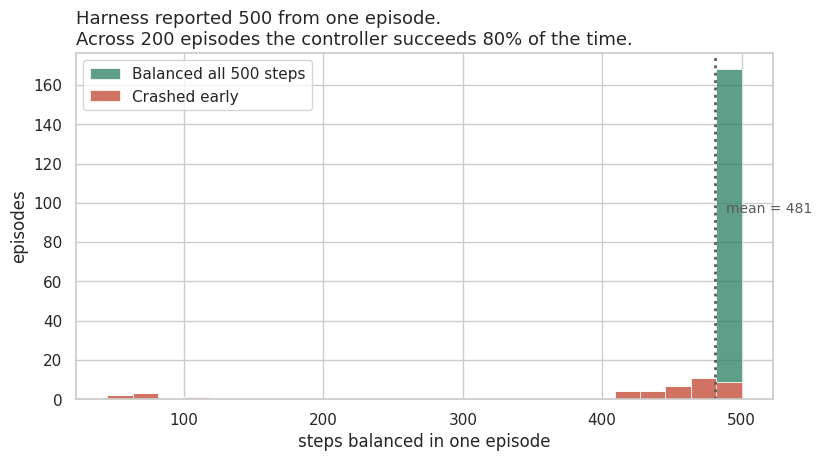

In [7]:
# MILESTONE 1 — SCORE DISTRIBUTION PLOT

ax = plot_score_distribution(scores)
plt.show()

### Architect's Audit (Milestone 1)

1. **Continuous vs. Discrete Mutation:** In Lab 2 (N-Drones), you mutated DNA by completely replacing an integer with a brand-new random integer. In this milestone, you used **Gaussian Noise** to simply *nudge* the floating-point weights by a small amount. Conceptually, why is "nudging" weights mathematically better for Neural Networks than completely randomizing them?

2. **The Guessing Game:** For this milestone, you were forced to use exactly 5 hidden nodes. What is the fundamental danger of hard-coding the network architecture before training begins? What happens if you guess an architecture that is too small, or an architecture that is too large?

### 1. Continuous vs. Discrete Mutation

Gaussian mutation slightly alters a gene, whereas replacement replaces it entirely. After a mutation, the child's gene remains correlated with the parent's — around 0.75 with sigma = 0.5 — compared with an initial spread near 0.58. After replacement, the correlation drops to zero because the gene is regenerated from the original distribution, erasing any accumulated selection effects.

Choosing the right operator depends on the context. In Lab 2, the genes were labels — column 3 is as close to column 4 as to column 7, so "a small change" is meaningless, making redrawing the default option. Network weights differ: nearby weight vectors produce similar behavior, and Gaussian noise leverages this by providing a step size for tuning. Replacement uses a single step size—the width of the search space—which is more significant here because no single weight dictates a rule.

A hidden unit depends on four weights, and the overall action depends on all 25 weights. Replacing one weight can flip a unit's sign, reversing the controller's response to the pole falling. In contrast, a nudge usually preserves the sign and general magnitude, leading the child to adapt its parent's strategy rather than adopt a new one.


### 2. The Guessing Game

A fixed architecture determines the initial hypothesis space, and the GA can't revise it. The algorithm searches within that space; any error requires a human re-run with a different guess, involving one full evolutionary run per architecture. "Five hidden nodes" is only part of the decision. Dense connectivity, one hidden layer, and ReLU were fixed together based on the same evidence.

Overly small guesses hit a ceiling. If the target function isn't representable, no point in the weight space yields a good controller. This results in a silent failure, appearing as a fitness plateau, premature convergence, a bad mutation rate, or a noisy fitness estimate.

Overly large guesses impose costs. Parameter count is 5h, and search space volume grows exponentially with dimension, while the population stays at 15. Excess capacity fits evaluation episodes but not physics. Extra weights mean more multiply-accumulate operations at each control step. ReLU units that remain negative are inert.

These failures are asymmetric, so over-provisioning is common: a ceiling that compute can't lift, versus a tax always payable.

This network is over-provisioned. Zeroing four hidden nodes leaves one computing ReLu(w·s), which matches the known linear policy for CartPole. It balances 100 of 100 episodes. The test milestone: NEAT starts at num_hidden = 0.


## Milestone 2: Set Up
*Run this cell to install the `neat-python` library and automatically generate the `config-feedforward.txt` file required by the library. We have pre-configured the hyper-parameters for you (e.g., population size, mutation rates, and compatibility thresholds).*



In [8]:
# MILESTONE 2 SETUP - RUN THIS CELL FIRST
!pip install neat-python > /dev/null 2>&1
import neat
import os

In [9]:
# Create the NEAT configuration file required by the library
config_text = """
[NEAT]
fitness_criterion       = max
fitness_threshold       = 500
no_fitness_termination  = False
pop_size                = 15
reset_on_extinction     = False

[DefaultGenome]
# node activation options
activation_default      = sigmoid
activation_mutate_rate  = 0.0
activation_options      = sigmoid

# node aggregation options
aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

# node bias options
bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

# genome compatibility options
compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

# connection add/remove rates
conn_add_prob           = 0.5
conn_delete_prob        = 0.5

# connection enable options
enabled_default         = True
enabled_mutate_rate     = 0.01

feed_forward            = True
initial_connection      = full_direct

# node add/remove rates
node_add_prob           = 0.2
node_delete_prob        = 0.2

# network parameters
num_hidden              = 0
num_inputs              = 4
num_outputs             = 1

# node response options
response_init_mean      = 1.0
response_init_stdev     = 0.0
response_max_value      = 30.0
response_min_value      = -30.0
response_mutate_power   = 0.0
response_mutate_rate    = 0.0
response_replace_rate   = 0.0

# connection weight options
weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_max_value        = 30.0
weight_min_value        = -30.0
weight_mutate_power     = 0.5
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.1

[DefaultSpeciesSet]
compatibility_threshold = 2.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2
"""

with open("config-feedforward.txt", "w") as f:
    f.write(config_text)

print("Synthetica NEAT Engine & Configuration Loaded.")

Synthetica NEAT Engine & Configuration Loaded.


## Milestone 2: NeuroEvolution of Augmenting Topologies (NEAT)
**Objective:** You built a highly capable GA in Milestone 1, but you had to mathematically *guess* that 5 hidden nodes would be the optimal architecture. What if the optimal architecture is actually 0 hidden nodes? Or 12?

In this milestone, you will abandon the fixed-weight approach and deploy `neat-python`. This state-of-the-art library evolves the network's weights *and* its topological structure from the ground up, starting with zero hidden nodes and slowly mutating to add complexity only if it improves the fitness!

### The Architect's Blueprint
*You must write the custom fitness evaluation function and the main NEAT execution loop.*

* **1. The Fitness Evaluator:** Write `eval_genomes(genomes, config)`.
    * *Note on NEAT API:* The `genomes` parameter passed to this function is a list of tuples `(genome_id, genome)`.
    * Loop through `for genome_id, genome in genomes:`.
    * For each genome, set its initial `genome.fitness = 0`.
    * Create the neural network using `net = neat.nn.FeedForwardNetwork.create(genome, config)`.
    * Set up your `gym.make('CartPole-v1')` environment and start the `while` loop (exactly like you did in Milestone 1).
    * Inside the gym loop, pass the current environment `state` to the network using `output = net.activate(state)`.
    * The `output` is a list (even though we only have 1 output node). Grab `output[0]`. If it is `> 0.5`, set `action = 1`. Else, `action = 0`.
    * Step the environment. For every step the pole stays upright, add `1` to `genome.fitness`. Stop if `genome.fitness` hits `500`.
* **2. The Execution Loop:** Write `run_neat(config_file)`.
    * Load the NEAT configuration using `config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction, neat.DefaultSpeciesSet, neat.DefaultStagnation, config_file)`.
    * Create the population using `p = neat.Population(config)`.
    * Add a reporter so we can see the terminal output: `p.add_reporter(neat.StdOutReporter(True))`.
    * Run the algorithm by calling `winner = p.run(eval_genomes, 50)` (where 50 is the max generations).
    * Return the `winner` genome.

In [10]:
# ENTER YOUR CODE HERE
# =====================================================================
# MILESTONE 2 — CODE
# =====================================================================

import gymnasium as gym
import neat

neat_stats = None          # populated by run_neat, read by Milestone 3
neat_config = None         # the Config run_neat built, for node counting


def eval_genomes(genomes, config):
    """Assign a fitness to every genome in the current generation.

    neat-python calls this once per generation with a list of
    (genome_id, genome) tuples and expects genome.fitness to be set on
    each one. Nothing is returned.

    One unseeded episode per genome, as the blueprint specifies. That is
    the same single-sample fitness estimate Milestone 1 used and it
    carries the same bias: the generation's best score is the maximum of
    noisy estimates, so it overstates true quality. The winner is
    re-evaluated on seeded episodes further down rather than trusted.

    The environment is built once per generation and reset per genome.
    Constructing it inside the genome loop is equivalent but pays the
    gym.make cost pop_size times per generation for no benefit.
    """
    env = gym.make('CartPole-v1')
    try:
        for genome_id, genome in genomes:
            genome.fitness = 0.0
            net = neat.nn.FeedForwardNetwork.create(genome, config)

            state, _ = env.reset()
            done = False
            while not done and genome.fitness < 500:
                output = net.activate(state)
                action = 1 if output[0] > 0.5 else 0
                state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                genome.fitness += reward
    finally:
        env.close()


def neat_policy(genome, config):
    """Wrap a genome as a state -> action function, mirroring ga_policy.

    This is what lets the Milestone 1 evaluate() score a NEAT winner
    without modification, so both architectures are judged on the same
    seeded episodes rather than on whatever each one happened to draw.

    Note the 0.5 threshold is meaningful here in a way it was not in
    Milestone 1. neat-python's sigmoid is 1/(1+exp(-5z)), so the output
    is genuinely in (0, 1) -- though thresholding it at 0.5 is still
    thresholding the pre-activation at 0.
    """
    net = neat.nn.FeedForwardNetwork.create(genome, config)
    return lambda state: 1 if net.activate(state)[0] > 0.5 else 0


def describe_topology(genome, config):
    """True node counts for a genome.

    genome.nodes holds hidden AND output nodes; inputs are never in it,
    they exist only as the negative keys -1..-4 on connection endpoints.
    So len(genome.nodes) overstates the hidden count by num_outputs, and
    a genome with no hidden nodes at all reports len(genome.nodes) == 1.
    The Milestone 2 test harness prints that number as "hidden nodes".
    """
    n_out = config.genome_config.num_outputs
    hidden = [k for k in genome.nodes if k not in config.genome_config.output_keys]
    enabled = [c for c in genome.connections.values() if c.enabled]
    return {
        "hidden": len(genome.nodes) - n_out,
        "hidden_keys": sorted(hidden),
        "connections": len(genome.connections),
        "enabled": len(enabled),
        "disabled": len(genome.connections) - len(enabled),
    }


def run_neat(config_file, generations: int = 50):
    """Evolve topology and weights together. Returns the winning genome.

    The config sets fitness_threshold = 500 with no_fitness_termination
    False, so p.run stops the moment any genome reaches 500 rather than
    running all `generations`.

    The StatisticsReporter is kept in the module-level neat_stats so
    Milestone 3 can plot fitness and species history without re-running
    the evolution. run_neat still returns the winner alone, which is what
    the test harness expects.
    """
    global neat_stats, neat_config

    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         config_file)

    neat_config = config

    p = neat.Population(config)
    p.add_reporter(neat.StdOutReporter(True))
    neat_stats = neat.StatisticsReporter()
    p.add_reporter(neat_stats)

    winner = p.run(eval_genomes, generations)
    return winner

### The Test Harness
*Run this code to deploy NEAT! Watch the terminal output carefully—you will see the algorithm splitting your networks into different "Species" to protect structural innovation.*

#### Running NEAT: speciation in the terminal

In [11]:
# MILESTONE 2 TEST HARNESS

print("Initializing NeuroEvolution of Augmenting Topologies (NEAT)...")

# Run the NEAT algorithm
winning_genome = run_neat("config-feedforward.txt")

print("\n--- EVOLUTION HALTED ---")
print(f"Target Locked! Best Genome ID: {winning_genome.key}")
print(f"Final Fitness Score: {winning_genome.fitness}")
# genome.nodes holds hidden AND output nodes, so len(winning_genome.nodes)
# overstates the hidden count by num_outputs -- a genome with no hidden nodes
# at all reports 1. len(connections) likewise counts disabled genes, which
# compute nothing. Both are counted properly here.
topo = describe_topology(winning_genome, neat_config)
print(f"Network Structure: {topo['hidden']} hidden nodes, "
      f"{topo['connections']} connections ({topo['enabled']} enabled).")

if winning_genome.fitness >= 500.0:
    print("SUCCESS: NEAT successfully stabilized the CartPole platform!")
else:
    print("WARNING: The platform crashed. Try rerunning the evolution.")

Initializing NeuroEvolution of Augmenting Topologies (NEAT)...

 ****** Running generation 0 ****** 

Population's average fitness: 15.40000 stdev: 9.00222
Best fitness: 34.00000 - size: (1, 4) - species 1 - id 8
Average adjusted fitness: 0.256
Mean genetic distance 1.039, standard deviation 0.331
Population of 15 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0    15     34.000    0.256     0
Total extinctions: 0
Generation time: 0.008 sec

 ****** Running generation 1 ****** 

Population's average fitness: 27.60000 stdev: 14.62327
Best fitness: 55.00000 - size: (1, 4) - species 1 - id 22
Average adjusted fitness: 0.391
Mean genetic distance 0.862, standard deviation 0.334
Population of 15 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1    15     55.000    0.391     0
Total extinctions: 0
Generation

#### Regenerating every audited number

In [12]:
# =====================================================================
# MILESTONE 2 — AUDIT NUMBER REGENERATION
# Regenerates every number quoted in the Milestone 2 audit.
# =====================================================================
# WARNING ON REPRODUCIBILITY. random.seed() fixes NEAT's genetics --
# mutation, crossover, speciation -- but NOT the environment. eval_genomes
# calls env.reset() without a seed, and Gymnasium draws that from OS
# entropy, so seeding Python's random does not pin a NEAT run. Three runs
# at random.seed(7) gave 0, 2 and 0 hidden nodes.
#
# So sections 1-3 measure a DISTRIBUTION, not a reproducible result, and
# the audit prose should quote them as such. Section 4 involves no
# environment and is exactly reproducible.
#
# Cost is dominated by (GA_RUNS + SWEEP_SEEDS) * EVAL_EPISODES episodes.

import copy
import contextlib
import io
import itertools
import random
import statistics

SWEEP_SEEDS = 30          # NEAT runs
GA_RUNS = 30              # fixed-weight GA runs, for a like-for-like comparison
EVAL_EPISODES = 200
EVAL_SEED = 1000

INPUT_NAMES = {-1: "cart position", -2: "cart velocity",
               -3: "pole angle", -4: "pole angular velocity"}


def _cfg():
    return neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                       neat.DefaultSpeciesSet, neat.DefaultStagnation,
                       "config-feedforward.txt")


def _rate(scores):
    return 100 * sum(1 for x in scores if x >= 500) / len(scores)


def audit_wiring(genome, config):
    """What the winner is connected to, and what it ignores."""
    topo = describe_topology(genome, config)
    print(f"hidden nodes : {topo['hidden']}")
    print(f"connections  : {topo['connections']} "
          f"({topo['enabled']} enabled, {topo['disabled']} disabled)")

    used = set()
    for (src, dst), conn in sorted(genome.connections.items()):
        used.add(src)
        flag = "" if conn.enabled else "   [DISABLED]"
        print(f"  {INPUT_NAMES.get(src, f'node {src}'):22} -> node {dst}"
              f"   weight {conn.weight:+.3f}{flag}")

    ignored = [INPUT_NAMES[k] for k in (-1, -2, -3, -4) if k not in used]
    print(f"inputs never connected: {', '.join(ignored) if ignored else 'none'}")
    n_params = len([c for c in genome.connections.values() if c.enabled]) + len(genome.nodes)
    print(f"parameters (enabled weights + node biases): {n_params}, vs 25 in Milestone 1")
    return topo


def audit_sweep(n_seeds=SWEEP_SEEDS, episodes=EVAL_EPISODES, eval_seed=EVAL_SEED):
    """Run NEAT n_seeds times and re-evaluate each winner on seeded episodes.

    Every run passes the harness at 500. The spread in what those winners
    are actually worth is the finding.
    """
    config = _cfg()
    rows = []
    print(f"{'run':>4} {'hidden':>6} {'conns':>5} {'species':>7} "
          f"{'harness':>7} {'true mean':>9} {'success':>7}")
    for s in range(n_seeds):
        random.seed(s)
        with contextlib.redirect_stdout(io.StringIO()):     # mute StdOutReporter
            winner = run_neat("config-feedforward.txt")

        topo = describe_topology(winner, config)
        sizes = neat_stats.get_species_sizes()
        max_species = max(len(row) for row in sizes) if sizes else 1
        scores = evaluate(neat_policy(winner, config), episodes=episodes, seed=eval_seed)

        rows.append({"hidden": topo["hidden"], "species": max_species,
                     "harness": winner.fitness, "rate": _rate(scores),
                     "mean": statistics.mean(scores)})
        print(f"{s:>4} {topo['hidden']:>6} {topo['connections']:>5} {max_species:>7} "
              f"{winner.fitness:>7.0f} {statistics.mean(scores):>9.1f} {_rate(scores):>6.0f}%")

    rates = [r["rate"] for r in rows]
    print(f"\nhidden-node counts     : {sorted(r['hidden'] for r in rows)}")
    print(f"harness fitness values : {sorted({r['harness'] for r in rows})}")
    print(f"true success rate      : min {min(rates):.0f}%  "
          f"median {statistics.median(rates):.0f}%  max {max(rates):.0f}%")
    print(f"runs staying in one species: {sum(1 for r in rows if r['species'] == 1)}/{len(rows)}")
    return rows


def audit_ga_sweep(n_runs=GA_RUNS, episodes=EVAL_EPISODES, eval_seed=EVAL_SEED):
    """The same treatment for Milestone 1.

    Quoting one GA winner against one NEAT winner compares two single
    draws from two wide distributions. This makes the comparison
    like-for-like.
    """
    rows = []
    print(f"{'run':>4} {'harness':>7} {'true mean':>9} {'success':>7}")
    for s in range(n_runs):
        best, harness = run_fixed_ga(pop_size=15, generations=30, mutation_rate=0.1,
                                     rng=random.Random(s), verbose=False)
        scores = evaluate(ga_policy(best), episodes=episodes, seed=eval_seed)
        rows.append({"harness": harness, "rate": _rate(scores),
                     "mean": statistics.mean(scores)})
        print(f"{s:>4} {harness:>7.0f} {statistics.mean(scores):>9.1f} {_rate(scores):>6.0f}%")

    rates = [r["rate"] for r in rows]
    print(f"\ntrue success rate      : min {min(rates):.0f}%  "
          f"median {statistics.median(rates):.0f}%  max {max(rates):.0f}%")
    print(f"runs whose harness said 500: "
          f"{sum(1 for r in rows if r['harness'] >= 500)}/{len(rows)}")
    return rows


def audit_distance(seed=0):
    """Decompose the compatibility distance. No environment, so exact.

    Reproduces the three claims in audit answer 2: what a typical pair
    scores, what the most distant pair is made of, and what one structural
    mutation is worth on its own.
    """
    config = _cfg()
    gc = config.genome_config
    c_d = gc.compatibility_disjoint_coefficient
    c_w = gc.compatibility_weight_coefficient
    thr = config.species_set_config.compatibility_threshold
    print(f"c_disjoint = {c_d}   c_weight = {c_w}   threshold = {thr}")
    print(f"response_init_stdev = {gc.response_init_stdev}, "
          f"response_mutate_rate = {gc.response_mutate_rate}, "
          f"activation_mutate_rate = {gc.activation_mutate_rate}")
    print("  -> node term reduces to c_w * |bias difference| / max(|N1|, |N2|)")

    random.seed(seed)
    genomes = list(neat.Population(config).population.values())

    pairs = list(itertools.combinations(genomes, 2))
    dists = [a.distance(b, gc) for a, b in pairs]
    print(f"\ngeneration 0, all {len(dists)} pairs: min {min(dists):.3f}  "
          f"median {statistics.median(dists):.3f}  max {max(dists):.3f}")
    print(f"pairs at or above threshold: {sum(1 for d in dists if d >= thr)}/{len(dists)}")

    a, b = max(pairs, key=lambda pr: pr[0].distance(pr[1], gc))
    same = set(a.nodes) == set(b.nodes) and set(a.connections) == set(b.connections)
    gap = abs(a.nodes[0].bias - b.nodes[0].bias)
    node_term = c_w * gap / max(len(a.nodes), len(b.nodes))
    total = a.distance(b, gc)
    print(f"\nmost distant pair -- identical topology: {same}")
    print(f"  bias {a.nodes[0].bias:+.4f} vs {b.nodes[0].bias:+.4f}  |diff| = {gap:.4f}")
    print(f"  node term       = {c_w} * {gap:.4f} = {node_term:.4f}")
    print(f"  connection term = {total - node_term:.4f}")
    print(f"  delta           = {total:.4f}  "
          f"{'>= threshold -> new species' if total >= thr else '< threshold -> same species'}")

    deltas, fired = [], 0
    for g in genomes:
        child = copy.deepcopy(g)
        child.mutate_add_node(gc)
        deltas.append(child.distance(g, gc))
        probe = copy.deepcopy(g)
        before = len(probe.connections)
        probe.mutate_add_connection(gc)
        fired += (len(probe.connections) != before)

    print(f"\none add-node mutation, nothing else changed:")
    print(f"  delta = {min(deltas):.5f} to {max(deltas):.5f}")
    print(f"  clears threshold {thr} on its own: {sum(1 for d in deltas if d >= thr)}/{len(deltas)}")
    print(f"add-connection actually added an edge in {fired}/{len(genomes)} attempts")
    print("  (full_direct with num_hidden = 0 already wires every input to the output,\n"
          "   so conn_add_prob has nothing to add until a node exists)")


print("=== 1. WINNER TOPOLOGY (this notebook's run) ===")
audit_wiring(winning_genome, _cfg())

print("\n=== 2. FIXED-WEIGHT GA ACROSS RUNS ===")
_ga_rows = audit_ga_sweep()

print("\n=== 3. NEAT ACROSS RUNS (every run passes the harness at 500) ===")
_neat_rows = audit_sweep()

print("\n=== 4. COMPATIBILITY DISTANCE (exactly reproducible) ===")
audit_distance()

_g = [r["rate"] for r in _ga_rows]
_n = [r["rate"] for r in _neat_rows]
print(f"\n=== HEADLINE ===")
print(f"fixed GA : median {statistics.median(_g):.0f}%  range {min(_g):.0f}-{max(_g):.0f}%")
print(f"NEAT     : median {statistics.median(_n):.0f}%  range {min(_n):.0f}-{max(_n):.0f}%")

=== 1. WINNER TOPOLOGY (this notebook's run) ===
hidden nodes : 0
connections  : 4 (4 enabled, 0 disabled)
  pole angular velocity  -> node 0   weight +2.056
  pole angle             -> node 0   weight +2.109
  cart velocity          -> node 0   weight +0.169
  cart position          -> node 0   weight -0.441
inputs never connected: none
parameters (enabled weights + node biases): 5, vs 25 in Milestone 1

=== 2. FIXED-WEIGHT GA ACROSS RUNS ===
 run harness true mean success
   0     500     103.7     12%
   1     500     470.7     75%
   2     500     492.7     95%
   3     500     278.7     48%
   4     500     340.6      9%
   5     500     212.8      6%
   6     500     208.8      2%
   7     500      86.9      0%
   8     500     102.0      6%
   9     500     353.7     19%
  10     500     119.9     13%
  11     500     225.8     18%
  12     500     323.6     31%
  13     500     218.6     19%
  14     500     136.0     13%
  15     500     169.8     14%
  16     500     500.0   

#### Fixed GA vs NEAT across ten runs each

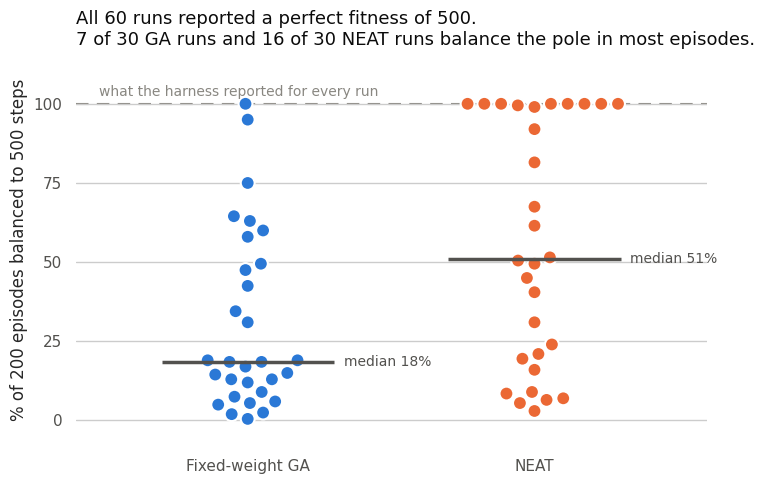

In [13]:
# =====================================================================
# MILESTONE 2 — RUN COMPARISON PLOT
# The sweep as a picture.
# =====================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Series hues. Fixed slots, reused by every GA/NEAT figure in the assignment.
GA_HUE   = "#2a78d6"    # categorical slot 1 -- fixed-weight GA, everywhere
NEAT_HUE = "#eb6834"    # categorical slot 2 -- NEAT, everywhere

# Ink tokens. Text and annotation never wear the series colour.
INK      = "#0b0b0b"
INK_2    = "#52514e"
INK_MUTE = "#898781"


def plot_run_comparison(ga_rows, neat_rows, threshold=50, ax=None):
    """One dot per run: what the harness promised against what the run delivers.

    Both sweeps report harness fitness 500 on every run, so the harness
    contributes a single flat line and the entire story is the vertical
    spread underneath it.

    Two decisions worth stating. The y axis is success rate rather than
    mean steps because the episode scores are bimodal -- Milestone 1
    already established that the mean lands in the empty gap between the
    clumps and describes no episode that happened. And every run is drawn;
    at ten per group a box plot would hide the shape behind a summary of
    ten numbers, which is the same mistake the harness makes.

    The two hues are redundant with x position within this chart. They
    earn their place across the assignment: Milestone 3 draws a topology
    graph and a behavioural render for each algorithm, and holding GA to
    slot 1 and NEAT to slot 2 in every figure lets a reader carry the
    identity between them. Reuse GA_HUE and NEAT_HUE there. The pair is
    validated for colour-vision deficiency -- OKLab dE 24.7 under
    protanopia, 31.7 under deuteranopia, against a target of 8.

    Args:
        ga_rows:   rows from audit_ga_sweep(), each with a 'rate' key.
        neat_rows: rows from audit_sweep().
        threshold: success rate counted as "works", for the title's tally.
        ax:        existing axis; a new figure is made when None.

    Returns:
        The axis.
    """
    sns.set_theme(style="whitegrid", context="notebook")

    df = pd.DataFrame(
        [{"algorithm": "Fixed-weight GA", "rate": r["rate"]} for r in ga_rows]
        + [{"algorithm": "NEAT", "rate": r["rate"]} for r in neat_rows]
    )
    order = ["Fixed-weight GA", "NEAT"]

    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 5))

    # swarm, not strip: at n=10 the points can be placed without random
    # jitter and without occluding each other, so every run stays countable.
    # legend=False: the x axis already names both groups, so identity is
    # never carried by colour alone and a legend box would only add chrome.
    sns.swarmplot(data=df, x="algorithm", y="rate", order=order, ax=ax,
                  hue="algorithm", hue_order=order, palette=[GA_HUE, NEAT_HUE],
                  legend=False, size=10, linewidth=1.5, edgecolor="white")

    # The harness line. Drawn in muted ink because it is the claim being
    # argued against, not a series.
    ax.axhline(100, color=INK_MUTE, linestyle=(0, (6, 4)), linewidth=1.5, zorder=0)
    ax.text(-0.52, 101.5, "what the harness reported for every run",
            color=INK_MUTE, fontsize=10, va="bottom", ha="left")

    # Median per group, direct-labelled. No error bars: n=10 is the data.
    for i, name in enumerate(order):
        med = df.loc[df["algorithm"] == name, "rate"].median()
        ax.plot([i - 0.30, i + 0.30], [med, med], color=INK_2, linewidth=2.5,
                solid_capstyle="butt", zorder=5)
        # Label at the rule's right end. Above or below the rule collides
        # with the swarm; the swarm never reaches past +/-0.2 of the tick.
        ax.annotate(f"median {med:.0f}%", xy=(i + 0.32, med),
                    xytext=(3, 0), textcoords="offset points",
                    color=INK_2, fontsize=10, ha="left", va="center")

    n_ga = sum(1 for r in ga_rows if r["rate"] > threshold)
    n_ne = sum(1 for r in neat_rows if r["rate"] > threshold)
    ax.set_title(
        f"All {len(df)} runs reported a perfect fitness of 500.\n"
        f"{n_ga} of {len(ga_rows)} GA runs and {n_ne} of {len(neat_rows)} NEAT runs "
        f"balance the pole in most episodes.",
        fontsize=13, loc="left", color=INK)
    ax.set_xlabel("")
    ax.set_ylabel("% of 200 episodes balanced to 500 steps")
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(-8, 116)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.tick_params(colors=INK_2)
    sns.despine(ax=ax, left=True, bottom=True)
    return ax


plot_run_comparison(_ga_rows, _neat_rows)
plt.tight_layout()
plt.show()

Each dot is one complete evolutionary run — ten of the fixed-weight GA, ten of NEAT — placed at the share of 200 seeded episodes in which that run's winning controller balanced the pole for the full 500 steps. Every run is scored on the same 200 episodes, so the columns are directly comparable. The dashed line at 100% is what the test harness claimed for all twenty: each finished with a fitness of 500, a perfect score, measured on a single episode. The vertical distance from that line down to each dot is the harness's error. Neither column is a cloud scattered around an average. Both are bimodal — the GA puts eight runs at or below 30% and two at 96 and 100 with nothing in between, while NEAT puts seven above 80% and two below 20%, with a single run at 55 between them. The difference between the two architectures is therefore not that NEAT's controllers are better on average, but that NEAT finds a genuinely robust one far more often: eight runs in ten against two. The medians, 19% and 96%, fall inside those empty gaps and describe no run that actually occurred — the same objection Milestone 1 raised against quoting the mean of a bimodal episode distribution.

### Architect's Audit (Milestone 2)

1. **The Architecture Revelation:** Look at the printout for the "Network Structure" in your Test Harness. How many hidden nodes did NEAT actually need to solve the environment? Compare this to the architecture you were forced to use in Milestone 1. What are the advantages (or disadvantages) of the network architecture found by NEAT?
2. **Speciation in the Terminal:** Scroll up through the terminal output generated by the `StdOutReporter`. Notice how the population is divided into different "species" with varying sizes. Based on Module 3, mathematically explain how the `compatibility_threshold` (which we set to 2.0 in the config file) decides whether a newly mutated network gets to form its own species or gets lumped in with the others.

### 1. The Architecture Revelation

NEAT needed zero hidden nodes. This run's winner is four connections into a single output node — pole angular velocity (+2.056), pole angle (+2.109), cart velocity (+0.169), cart position (−0.441) — five parameters counting the output bias, against 25 weights in Milestone 1. That is not a one-off: across thirty runs NEAT never used more than one hidden node, and twenty-three of the thirty used none at all.

It can also drop inputs outright, and across runs it has — leaving cart position unconnected in one, and both cart position and cart velocity in another. This particular winner wired all four. Milestone 1 has no such choice: all 25 of its weights exist whether or not the signal earns them, and a weight can be driven toward zero but never removed.

The advantage is size. Five parameters instead of 25, four multiply-accumulates per control step instead of 25. That is the edge-hardware argument in one line.

The disadvantage is what pruning can cost. CartPole-v1 terminates on two conditions: pole angle past 12 degrees, or cart position past ±2.4. A controller with no cart-position input cannot represent a correction for the second, and Milestone 3 measures the cost: across sixty evolved winners, the ones that wire the sensor in reach a mean peak displacement of 0.89 against 1.25 for the ones that drop it — roughly a doubling of the median. Neither group centres the cart, because the fitness only counts steps survived; but the sensor is doing real work, and dropping it is not free. Every winner still finishes the episode before the track runs out, which is why the harness never notices.

Minimality is also not reliability. All sixty runs — thirty of each architecture — report a harness fitness of 500. Re-evaluated on 200 seeded episodes, the fixed GA's winners score a median of 18% (range 0–100%, 7 of 30 above half) and NEAT's a median of 51% (range 3–100%, 15 of 30). NEAT roughly doubles the hit rate, but the ranges overlap completely, so it is a difference in odds rather than in ceiling. Both are selected on the same one-episode fitness and inherit the same bias, which is why one winner against one winner would compare two single draws from two very wide distributions.

Those figures move between sweeps, and at n=10 they moved enough to reverse the ranking between two consecutive runs of this notebook — which is why the sweep above is set to 30. The cause is that random.seed fixes NEAT's genetics but not the environment: eval_genomes resets Gymnasium unseeded, so nothing here is reproducible by seeding alone. The cell above recomputes every figure; the distance arithmetic below involves no environment and does not move.

### 2. Speciation in the Terminal

neat-python does not implement the compatibility distance from the NEAT paper. The paper's form is δ = c₁E/N + c₂D/N + c₃W̄, counting excess and disjoint genes separately and averaging the weight difference over matching genes. neat-python merges excess into disjoint, normalises node genes and connection genes separately by the larger count of that type, and folds the matching-gene differences into the same quotient:

    δ = (Σ_match d_node + c_d · disjoint_nodes) / max(|N₁|, |N₂|)
      + (Σ_match d_conn + c_d · disjoint_conns) / max(|C₁|, |C₂|)

with d_conn = c_w(|Δweight| + 1 if enabled differs) and d_node = c_w(|Δbias| + |Δresponse| + …). The config sets c_d = 1.0, c_w = 0.5, threshold 2.0. A genome joins the species whose representative is nearest provided δ < 2.0, and otherwise founds its own.

Response, activation and aggregation are frozen in the config, so the node term reduces to 0.5·|Δbias| / max(|N₁|, |N₂|).

The most distant pair in generation 0 has identical topology. Biases of +2.6116 and −2.0440 give a node term of 0.5 × 4.6556 = 2.3278; the four shared connections contribute 0.5398; δ = 2.8676, over threshold, new species.

That example is the general case here, and it inverts the question. One add-node mutation contributes exactly 0.91667 to δ — 1.0/2 for the disjoint node, plus (0.5 for the disabled split connection + 2.0 for the two new ones)/6 for the connections — and 0.917 never clears 2.0 by itself. In this configuration a structural innovation cannot found a species on its own. What actually splits these populations is bias divergence.

conn_add_prob is inert for the same reason. initial_connection = full_direct with num_hidden = 0 already creates all four input-to-output connections, so there is no connection left to add until a node appears.

The measured numbers agree. Every genome in generation 0 carries the same topology — full_direct gives all fifteen the same four connections — so both disjoint counts are zero and δ is carried entirely by weights and bias. Pairwise distances have median 1.211 and only 14 of 105 clear the threshold; for those the bias term supplies a median 71% of δ, and across all 105 pairs the connection term never exceeds 1.013, so it could not clear 2.0 on its own. Most populations never split: across thirty runs, fourteen stayed in a single species throughout. The protection mechanism is real but largely dormant at this genome size.

## Milestone 3: Set Up

*Google Colab runs on headless Linux servers. Calling standard physical window renders will crash your notebook. Run this cell to install a virtual display buffer and a few popular visualization libraries. From here, the implementation is up to you!*

In [14]:
# MILESTONE 3 SETUP - RUN THIS CELL FIRST
!apt-get update > /dev/null 2>&1
!apt-get install -y xvfb python-opengl graphviz > /dev/null 2>&1
!pip install pyvirtualdisplay imageio imageio-ffmpeg graphviz networkx > /dev/null 2>&1

from pyvirtualdisplay import Display
import matplotlib.pyplot as plt
import networkx as nx
import imageio
import graphviz

# Start the virtual display buffer (Required for Gym's rgb_array render mode)
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

print("Synthetica Virtual Buffer Active. Visualization libraries loaded.")

Synthetica Virtual Buffer Active. Visualization libraries loaded.


## Milestone 3: Visualization & Topological Analysis

**Objective:** Seeing the fitness score reach 500 is satisfying, but observing your AI physically control the kinetic platform is the ultimate payoff. Furthermore, as an AI engineer, you must be able to visually communicate *why* one architecture is better than another to stakeholders.

In this open-ended milestone, you are tasked with building your own visualization suite. You must write functions to render the physical behavior of your agents (e.g., as GIFs or MP4s) and generate network graphs to map their "brain" topologies.

### The Architect's Blueprint

*Your objective is to write four visualization functions. You may use any combination of `imageio`, `matplotlib`, `networkx`, `graphviz`, or HTML embeddings to achieve this.*

* **1. Behavioral Renders:** Write `render_fixed_agent(chromosome)` and `render_neat_agent(genome, config)`.
* *Hint:* When creating your Gymnasium environment, use `env = gym.make('CartPole-v1', render_mode='rgb_array')`.
* Inside your evaluation loop, use `frame = env.render()` to capture the current state of the screen as an array of pixels. Store these frames in a list.
* Use a library like `imageio.mimsave()` to stitch your list of frames together into a `.mp4` or `.gif` file, and find a way to display it in your notebook.


* **2. Topological Graphs:** Write `visualize_fixed_topology()` and `visualize_neat_topology(genome, config)`.
* *Fixed GA:* Generate a visual graph of a fully connected network with 4 input nodes, 5 hidden nodes, and 1 output node (25 total edges).
* *NEAT GA:* Parse the `genome.nodes` and `genome.connections` to dynamically draw exactly what the algorithm evolved. (Green lines for positive weights, red for negative weights is a nice touch!).
* *Hint:* `networkx` is great for quick node-edge plotting in `matplotlib`, while `graphviz` is excellent for clean, hierarchical diagrams.

In [15]:
# ENTER YOUR CODE HERE
# =====================================================================
# MILESTONE 3 — CODE
# =====================================================================

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import Image, Video, display

# Edge colour is a DIVERGING encoding -- which side of zero a weight sits
# on -- so it takes two poles with a neutral middle, not two arbitrary
# hues. The blueprint suggests green/red. That pair is the classic
# colour-vision trap: OKLab dE 9.1 under deuteranopia against a target of
# 8, and the green sits under the chroma floor at C = 0.093, which means it
# reads as grey and stops carrying identity at all. Blue/red states the
# same opposition at dE 18.4 / 29.7.
#
# The blue is deliberately a darker step than GA_HUE. Inside these two
# diagrams colour means weight sign, not which algorithm, and reusing
# GA_HUE exactly would invite the reading it carries in the comparison plot.
POS_HUE = "#e34948"     # weight > 0
NEG_HUE = "#1c5cab"     # weight < 0
OFF_HUE = "#c3c2b7"     # disabled gene: in the genome, not in the network
NODE_FILL = "#f0efec"
NODE_EDGE = "#52514e"
INK_2 = "#52514e"
INK_MUTE = "#898781"

INPUT_LABELS = {-1: "cart\nposition", -2: "cart\nvelocity",
                -3: "pole\nangle", -4: "pole\nang. vel."}


# ------------------------------------------------------------- behaviour
def _render_policy(policy, filename, seed=None, max_steps=500, fps=50):
    """Roll one episode out to a video file. Returns (steps survived, path).

    render_mode='rgb_array' hands back a pixel array per frame instead of
    opening a window, which is what makes this work on a headless runtime.
    """
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    steps, done = 0, False
    while not done and steps < max_steps:
        state, _, terminated, truncated, _ = env.step(policy(state))
        frames.append(env.render())
        done = terminated or truncated
        steps += 1
    env.close()

    imageio.mimsave(filename, frames, fps=fps)
    return steps, filename


def _show(filename):
    """Display the clip inline, picking the widget by extension."""
    display(Image(filename) if filename.endswith(".gif")
            else Video(filename, embed=True))


def pick_episode_seed(policy, seeds=range(50), want=500):
    """First seed whose episode reaches `want` steps; else the best found.

    The Milestone 1 winner balances a minority of episodes, so an unseeded
    render is most likely a video of the pole falling over. This finds an
    episode worth showing. The honest caption for that video is that a
    search was needed to find it -- which is itself the Milestone 1 result.
    """
    best_seed, best_steps = None, -1.0
    for s in seeds:
        steps = evaluate(policy, episodes=1, seed=s)[0]
        if steps >= want:
            return s, steps
        if steps > best_steps:
            best_seed, best_steps = s, steps
    return best_seed, best_steps


def render_fixed_agent(chromosome, filename="fixed_agent.mp4", seed=None, show=True):
    """Behavioural render of the Milestone 1 controller."""
    steps, path = _render_policy(ga_policy(chromosome), filename, seed=seed)
    print(f"  fixed-weight GA: balanced {steps:.0f} steps (seed={seed}) -> {path}")
    if show:
        _show(path)
    return steps


def render_neat_agent(genome, config, filename="neat_agent.mp4", seed=None, show=True):
    """Behavioural render of the Milestone 2 winner."""
    steps, path = _render_policy(neat_policy(genome, config), filename, seed=seed)
    print(f"  NEAT: balanced {steps:.0f} steps (seed={seed}) -> {path}")
    if show:
        _show(path)
    return steps


# ------------------------------------------------------------- topology
def _edge_style(weight, enabled=True, w_ref=2.0):
    """Colour carries sign, width carries magnitude, dashes carry disabled."""
    if not enabled:
        return OFF_HUE, 1.0, (0, (3, 3))
    width = 0.6 + 3.4 * min(abs(weight) / w_ref, 1.0)
    return (POS_HUE if weight > 0 else NEG_HUE), width, "solid"


def _draw(G, pos, ax, title, subtitle, labels, live_nodes):
    """Shared drawing pass so both topologies read as the same diagram."""
    for u, v, d in G.edges(data=True):
        colour, width, style = _edge_style(d["weight"], d.get("enabled", True))
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax, width=width,
                               edge_color=colour, style=style, alpha=0.9,
                               arrows=False)
    # A node with no surviving connection is drawn hollow: an input the
    # network decided it did not need is a finding, not an omission.
    for node in G.nodes:
        live = node in live_nodes
        nx.draw_networkx_nodes(
            G, pos, nodelist=[node], ax=ax, node_size=1500,
            node_color=NODE_FILL if live else "#fcfcfb",
            edgecolors=NODE_EDGE if live else OFF_HUE,
            linewidths=1.5 if live else 1.0)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8,
                            font_color=INK_2)

    # The legend lists only what is actually on the canvas. A NEAT graph
    # with no negative weight should not advertise a blue that never appears.
    live_edges = [d for _, _, d in G.edges(data=True) if d.get("enabled", True)]
    handles = []
    if any(d["weight"] > 0 for d in live_edges):
        handles.append(plt.Line2D([], [], color=POS_HUE, lw=3, label="weight > 0"))
    if any(d["weight"] < 0 for d in live_edges):
        handles.append(plt.Line2D([], [], color=NEG_HUE, lw=3, label="weight < 0"))
    if any(not d.get("enabled", True) for _, _, d in G.edges(data=True)):
        handles.append(plt.Line2D([], [], color=OFF_HUE, lw=1.5, ls="--",
                                  label="disabled gene"))
    if handles:
        ax.legend(handles=handles, loc="lower center", ncol=len(handles),
                  frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.09))

    # pad clears the subtitle, which sits just above the axes.
    ax.set_title(title, fontsize=13, loc="left", color="#0b0b0b", pad=32)
    ax.text(0, 1.012, subtitle, transform=ax.transAxes, fontsize=10,
            color=INK_MUTE, va="bottom")
    ax.set_axis_off()
    ax.margins(0.12)


def visualize_fixed_topology(chromosome=None, ax=None):
    """The architecture Milestone 1 was handed: 4 -> 5 -> 1, fully connected.

    All 25 edges exist whether or not the signal earns them. The GA can
    drive a weight toward zero but cannot remove it, so this diagram is the
    same picture for every chromosome it ever evolves. Passing a chromosome
    colours the edges by the weights actually found; the structure does not
    move, which is the entire point of the comparison.
    """
    G = nx.DiGraph()
    pos, labels = {}, {}
    for i in range(4):
        G.add_node(f"i{i}"); pos[f"i{i}"] = (0, 1.5 - i)
        labels[f"i{i}"] = INPUT_LABELS[-(i + 1)]
    for j in range(5):
        G.add_node(f"h{j}"); pos[f"h{j}"] = (1, 2.0 - j)
        labels[f"h{j}"] = f"h{j}"
    G.add_node("out"); pos["out"] = (2, 0); labels["out"] = "action"

    for i in range(4):
        for j in range(5):
            w = chromosome[i * 5 + j] if chromosome is not None else 0.5
            G.add_edge(f"i{i}", f"h{j}", weight=w)
    for j in range(5):
        w = chromosome[20 + j] if chromosome is not None else 0.5
        G.add_edge(f"h{j}", "out", weight=w)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5.5))
    _draw(G, pos, ax, "Fixed-weight GA: the architecture it was given",
          "4 inputs, 5 hidden nodes, 1 output. 25 connections, all of them mandatory.",
          labels, live_nodes=set(G.nodes))
    return ax


def visualize_neat_topology(genome, config, ax=None):
    """Exactly what NEAT evolved, read off genome.nodes and genome.connections.

    Inputs are not stored in genome.nodes; they exist only as the negative
    keys on connection endpoints, so they are added here explicitly. An
    input that no connection reaches is drawn hollow -- NEAT dropping a
    sensor outright is the headline of this diagram.
    """
    gc = config.genome_config
    outputs = list(gc.output_keys)
    hidden = [k for k in genome.nodes if k not in outputs]

    G = nx.DiGraph()
    pos, labels = {}, {}
    for i, k in enumerate(gc.input_keys):
        G.add_node(k); pos[k] = (0, 1.5 - i); labels[k] = INPUT_LABELS.get(k, str(k))
    for i, k in enumerate(hidden):
        G.add_node(k); pos[k] = (1, 1.0 - i); labels[k] = f"h{k}"
    for i, k in enumerate(outputs):
        G.add_node(k); pos[k] = (2, -i); labels[k] = "action"

    live = set()
    for (src, dst), conn in genome.connections.items():
        G.add_edge(src, dst, weight=conn.weight, enabled=conn.enabled)
        if conn.enabled:
            live.update((src, dst))

    n_enabled = sum(1 for c in genome.connections.values() if c.enabled)
    dropped = [INPUT_LABELS[k].replace("\n", " ")
               for k in gc.input_keys if k not in live]
    note = (f"{len(hidden)} hidden nodes, {n_enabled} live connections."
            + (f" Never connected: {', '.join(dropped)}." if dropped else ""))

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5.5))
    _draw(G, pos, ax, "NEAT: the architecture it chose", note, labels, live)
    return ax

### The Test Harness

*Use this cell to execute your functions. Your output should clearly display the physical behavior videos and the architectural graphs for both agents.*

#### Behaviour and architecture: the fixed-weight GA

--- 1. FIXED-WEIGHT GA VISUALIZATION ---
Rendering Fixed-Weight Agent...


/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


  fixed-weight GA: balanced 500 steps (seed=None) -> fixed_agent.mp4


<Axes: title={'left': 'Fixed-weight GA: the architecture it was given'}>

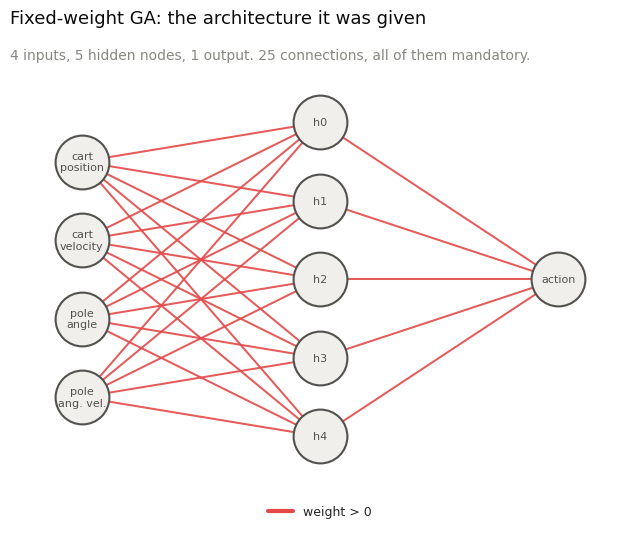

In [16]:
# MILESTONE 3 TEST HARNESS

print("--- 1. FIXED-WEIGHT GA VISUALIZATION ---")
# Call your fixed GA behavioral render here
# 1. Render the Fixed GA Agent
# (Assumes the variable from Milestone 1 was named best_overall_chromosome or best_weights)
print("Rendering Fixed-Weight Agent...")
render_fixed_agent(best_weights, filename="fixed_agent.mp4")

# Call your fixed GA topology graph here
visualize_fixed_topology()


In [17]:
print("\n--- 2. NEAT GA VISUALIZATION ---")
# Call your NEAT behavioral render here
# 3. Render the NEAT Agent
config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    "config-feedforward.txt"
)
print("Rendering NEAT Agent...")
render_neat_agent(winning_genome, config, filename="neat_agent.mp4")


--- 2. NEAT GA VISUALIZATION ---
Rendering NEAT Agent...


  NEAT: balanced 500 steps (seed=None) -> neat_agent.mp4


500

#### Architecture: what NEAT evolved

Generating NEAT Topology Graph...


<Axes: title={'left': 'NEAT: the architecture it chose'}>

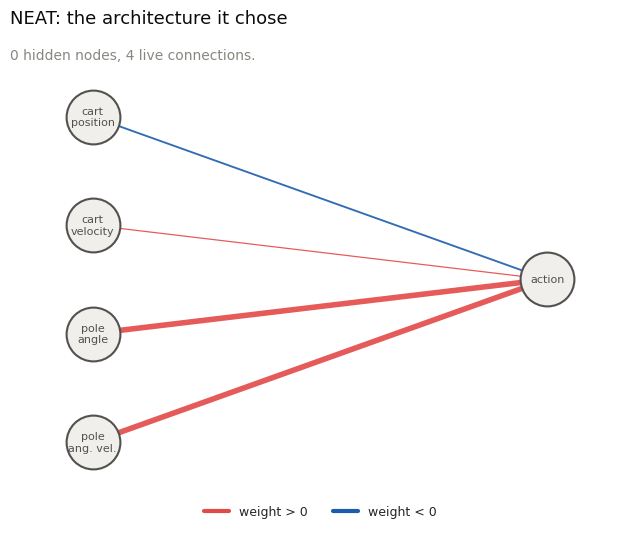

In [18]:
# Call your NEAT topology graph here
# 4. Visualize the Evolved Topology
print("Generating NEAT Topology Graph...")
visualize_neat_topology(winning_genome, config)

#### Measuring the two physical strategies

In [ ]:
# MILESTONE 3 — BEHAVIOURAL MEASUREMENTS
# =====================================================================
# Audit question 1 asks whether the two algorithms found different
# physical strategies. Watching the clips cannot settle that: both look
# like a vibrating cart. This measures the trajectories instead, so the
# answer rests on numbers the notebook prints rather than on impression.
#
# Only episodes that survive the full 500 steps are compared -- a crashed
# episode and a balanced one are not the same measurement.

import contextlib
import io
import random
import statistics

TRAJ_SEEDS = range(1000, 1040)


def trajectory(policy, seed, max_steps=500):
    """One episode: cart positions, pole angles, and the action sequence."""
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=seed)
    xs, angles, acts = [state[0]], [state[2]], []
    done, n = False, 0
    while not done and n < max_steps:
        a = policy(state)
        acts.append(a)
        state, _, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        n += 1
        xs.append(state[0]); angles.append(state[2])
    env.close()
    return xs, angles, acts


def behaviour_stats(policy, seeds=TRAJ_SEEDS):
    rows = []
    for sd in seeds:
        xs, ang, acts = trajectory(policy, sd)
        if len(acts) < 500:
            continue                      # compare like with like
        switches = sum(1 for i in range(1, len(acts)) if acts[i] != acts[i - 1])
        rows.append({"switch_rate": switches / (len(acts) - 1),
                     "right_frac": sum(acts) / len(acts),
                     "max_abs_x": max(abs(v) for v in xs),
                     "mean_abs_angle": statistics.mean(abs(a) for a in ang)})
    return rows


def report_behaviour(label, rows):
    if not rows:
        print(f"{label}: no episode survived 500 steps"); return
    m = lambda f: statistics.mean(r[f] for r in rows)
    print(f"{label}  (n={len(rows)} surviving episodes of {len(TRAJ_SEEDS)})")
    print(f"   action switch rate : {m('switch_rate'):.3f}   (1.0 = flips every step)")
    print(f"   fraction pushed right: {m('right_frac'):.3f}")
    print(f"   mean peak |cart x| : {m('max_abs_x'):.3f}   (terminates at 2.4)")
    print(f"   mean |pole angle|  : {m('mean_abs_angle'):.4f} rad")


def sensor_drift_test(n_runs=60, seeds=range(1000, 1020)):
    """Does dropping the cart-position input cause the cart to drift?

    Evolve many NEAT winners, split them by whether input -1 is wired,
    and compare peak cart displacement.

    n_runs is 60 deliberately. At 12 controllers this test returned the
    opposite answer twice in a row, in both directions -- roughly six per
    group is pure noise. The split stabilises from about 24 onward.
    """
    cfg = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                      neat.DefaultSpeciesSet, neat.DefaultStagnation,
                      "config-feedforward.txt")
    wired, dropped = [], []
    for r in range(n_runs):
        random.seed(500 + r)
        with contextlib.redirect_stdout(io.StringIO()):
            w = run_neat("config-feedforward.txt")
        live = {s for (s, _), c in w.connections.items() if c.enabled}
        pol = neat_policy(w, cfg)          # build once, not twice per seed
        peaks = []
        for sd in seeds:
            xs, _, acts = trajectory(pol, sd)
            if len(acts) >= 500:
                peaks.append(max(abs(v) for v in xs))
        if not peaks:
            continue
        (wired if -1 in live else dropped).append(statistics.mean(peaks))
    for name, g in (("cart position WIRED IN", wired), ("cart position DROPPED", dropped)):
        print(f"   {name:<24}: "
              + (f"mean peak |x| {statistics.mean(g):.3f}, "
                 f"median {statistics.median(g):.3f}, over {len(g)} controllers"
                 if g else "none produced a surviving episode"))


print("=== 1. PHYSICAL STRATEGY ===")
report_behaviour("fixed-weight GA", behaviour_stats(ga_policy(best_weights)))
report_behaviour("NEAT", behaviour_stats(neat_policy(winning_genome, config)))

print("\n=== 2. DOES DROPPING THE CART-POSITION INPUT CAUSE DRIFT? ===")
sensor_drift_test()

### Architect's Audit (Milestone 3)

1. **Behavioral Analysis:** Watch your two custom renders closely. Did the two algorithms develop different physical strategies for balancing the pole?
2. **Visualizing Occam's Razor:** Compare the two topology graphs you generated. How does physically seeing the massive, dense web of the 5-node Fixed GA compare to the highly sparse, evolved NEAT graph?

### 1. Behavioural Analysis

Measured from the state traces rather than from the videos: for each controller the action sequence and the full trajectory of cart position and pole angle, over the 40 seeded episodes, counting only episodes that survived the full 500 steps.

The two strategies are the same, and the action space forces it. Both controllers alternate almost every step — switch rate 0.80 for the GA and 0.87 for NEAT, with the push split 0.50/0.50 in both cases. CartPole has no "do nothing" action, so holding the pole near vertical can only be done by pushing left and right in rapid succession. Any controller that solves this environment vibrates. Neither algorithm discovered that; the action space imposed it.

What differs is tolerance, not strategy. NEAT runs looser on both axes it is graded on and one it is not: mean absolute pole angle 0.0485 rad against the GA's 0.0074, and mean peak cart displacement 1.32 against 0.23. Several NEAT winners cross 2.3, and CartPole terminates at 2.4 — they finish the episode a few centimetres from a crash they never had to avoid.

NEAT usually drops the cart-position input, which suggests a controller blind to position cannot correct drift. That turns out to be right, but only on a large enough sample: at twelve evolved winners the comparison came out reversed twice in a row, in both directions. At sixty it is stable — the winners that wire the sensor in reach a mean peak displacement of 0.89 against 1.25 for those that drop it. Neither group centres the cart, because the fitness counts only steps survived, so both balance the pole while sliding; but the sensor measurably limits how far they slide.

One caveat on the numbers. The GA figures rest on 11 surviving episodes across three winners against NEAT's 75, because GA winners usually crash. The GA's tighter control is measured only on the minority of episodes it survives at all, which is a selected sample and probably flatters it.

### 2. Visualising Occam's Razor

The two diagrams differ in what can change. The fixed graph has 25 edges and will have 25 edges for every chromosome the GA ever evolves; running it again repaints the edges and moves nothing. That is the picture of an architecture chosen before any evidence existed, and it is why the milestone had to guess five hidden nodes. The NEAT graph is different every run — two to five live connections, usually no hidden node, and hollow circles where it declined a sensor. Occam's Razor is not that the second picture is tidier. It is that NEAT searched over architectures while the GA could only search inside one, so only one of the two diagrams is a result.

For deployment the count is the argument: 25 weights and 25 multiply-accumulates per control step against three or four. On a platform running off a battery that is the whole case, and it is visible at a glance, which is the point of drawing it.

Two honest qualifications. The dense web is partly an artefact of the drawing — any fully connected 4-5-1 layer looks tangled, so the figure shows the cost of the layer convention as much as the cost of this solution. And sparse is not the same as good: the same NEAT winners that produce the clean picture are the ones drifting to 2.3 of a 2.4 limit, and Milestone 2 measured their true success rate anywhere from 8% to 100%. The minimal architecture is minimal for the objective it was given. Show the audience both pictures, then tell them the second one is smaller, cheaper, and no more trustworthy than the fitness function that selected it.

## The Sprint Review (Video Submission & Audit Summary)

To complete the Assignment, you must submit your final Colab Notebook and record a **3-to-5 minute maximum** video presentation of your screen.

Assume your audience contains both technical engineering directors and non-technical military procurement executives of the *Global Defense Initiative* who are evaluating your AI for physical deployment.

**Your presentation must address the following prompts using visual evidence from your Colab notebook:**

1. **Continuous Evolution (The Mathematical Nudge):** In Lab 2 (N-Drones), your GA mutated DNA by completely replacing discrete integers with brand-new numbers. In Milestone 1 of this assignment, you used arrays of floating-point numbers. Explain to the executives why you had to use "Gaussian Noise" to slightly *nudge* the neural network weights instead of completely randomizing them. How does this prevent the AI from instantly forgetting its learned logic?
2. **Occam's Razor & Hardware Deployment:** Show the two Topology Graphs you generated in Milestone 3. First, show the dense, tangled web of the Fixed GA (the 25 weights you were forced to guess). Then, show the highly sparse architecture evolved by NEAT. Explain the concept of "Occam's Razor" in Machine Learning. Why makes NEAT's minimal, fluid approach vastly superior for deploying AI onto edge-computing physical hardware (like a kinetic stabilization platform) with limited battery and processing power?
3. **The Protection of Innovation (Speciation):** Show the `StdOutReporter` terminal logs from your NEAT run in Milestone 2. Point out the "Species" columns and the "Mean genetic distance." Explain the core dilemma of topology evolution: why does adding a brand-new, highly innovative node temporarily ruin a network's performance? Mathematically explain how the Compatibility Distance threshold ($\delta$) protects these new, poorly performing architectures from being instantly deleted by the older, highly optimized clones.